## Ayudantía #1
### Metodos a repasar:
- Gradiente-descendente:
    1. Dirección normalizada
    2. Paso fijo
- Newton-Raphson


----
## Gradiente-Descendente con dirección normalizada
De la misma manera vista en clase, este metodo utiliza solo la dirección del punto evaluado en la gradiente para acercarse a un minimo local con una constante de aprendizaje. Esto se representa de la siguiente forma:

$$ \ x_{i+1} = x_i - \frac{ʎ*f'(x_i)}{|f'(x_i)|} $$

De manera visual, con curvas de nivel para la función $$ x^2 + 2y^2 $$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


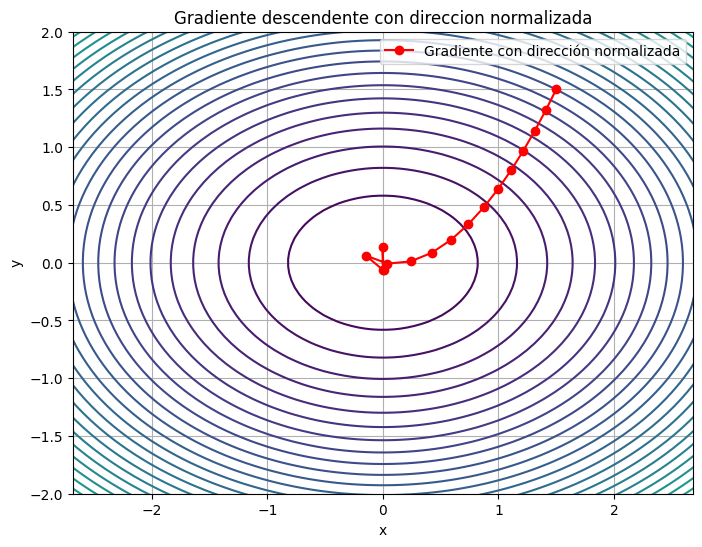

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return x**2 + 2*y**2

def grad_f(x, y):
    return np.array([2*x, 4*y])

x_vals = [1.5]
y_vals = [1.5]
alpha = 0.2  # paso fijo

for _ in range(15):
    grad = grad_f(x_vals[-1], y_vals[-1])
    grad_norm = grad/np.linalg.norm(grad)
    x_new = x_vals[-1] - alpha*grad_norm[0]
    y_new = y_vals[-1] - alpha*grad_norm[1]
    x_vals.append(x_new)
    y_vals.append(y_new)

plt.contour(np.linspace(-3,3,100), np.linspace(-3,3,100), 
            [[f(x,y) for x in np.linspace(-2,2,100)] for y in np.linspace(-2,2,100)], levels=40)
plt.plot(x_vals, y_vals, 'ro-', label='Gradiente con dirección normalizada')
plt.legend()
plt.title("Gradiente descendente con direccion normalizada")
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gcf().set_size_inches(8, 6)
plt.show()

para una funcion de una dimension

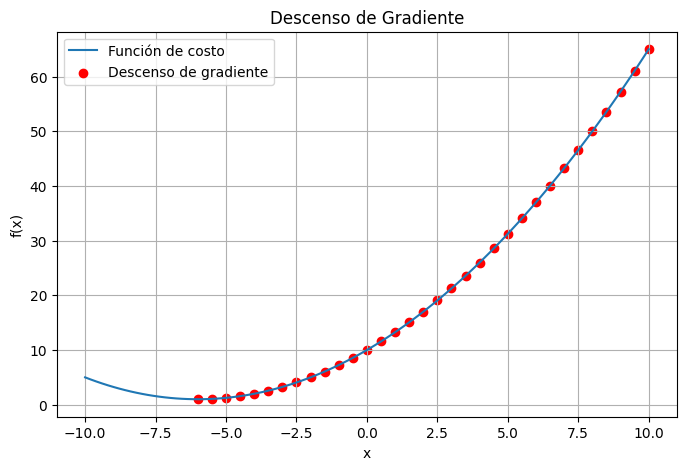

In [2]:
def f(x):
    y = 1/4*x**2 + 3*x +10     
    return y

def df(x):
    y = 1/2*x +3    #Primera derivada de la Segunda función
    return y

x = 10  # Valor inicial
learning_rate = 0.5
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)/np.linalg.norm(df(x))
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(-10, 10, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()

----
## Gradiente-Descendente con paso fijo
En este caso, el método utiliza tanto la direccion como el valor numerico del punto evaluado en la gradiente de la función para acercarse a un minimo local con una constante de aprendizaje, es decir, la diferencia del punto inicial con el siguiente varia dependiendo de la pendiente de la función:

$$ \ x_{i+1} = x - ʎ*f'(x_i) $$

De manera visual, el ejemplo anterior con este nuevo metodo: $$ x^2 + 2y^2 $$


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


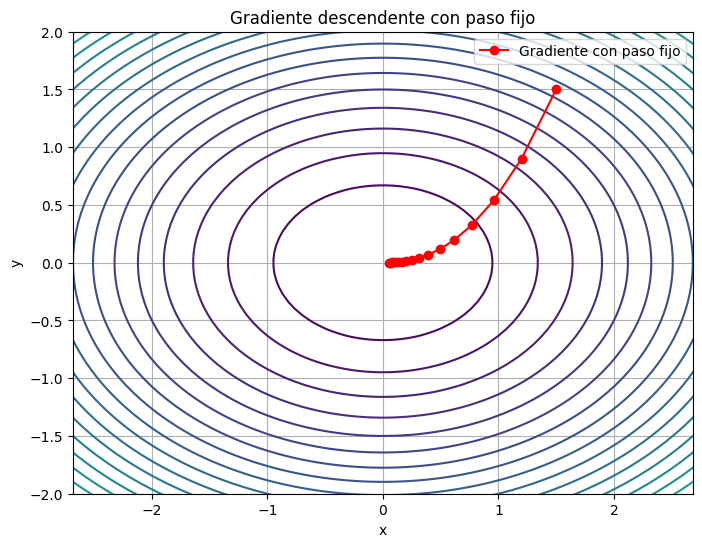

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
def f(x, y):
    return x**2 + 2*y**2

def grad_f(x, y):
    return np.array([2*x, 4*y])

x_vals = [1.5]
y_vals = [1.5]
alpha = 0.1  # paso fijo

for _ in range(15):
    grad = grad_f(x_vals[-1], y_vals[-1])
    x_new = x_vals[-1] - alpha*grad[0]
    y_new = y_vals[-1] - alpha*grad[1]
    x_vals.append(x_new)
    y_vals.append(y_new)

plt.contour(np.linspace(-3,3,100), np.linspace(-3,3,100), 
            [[f(x,y) for x in np.linspace(-2,2,100)] for y in np.linspace(-2,2,100)], levels=30)
plt.plot(x_vals, y_vals, 'ro-', label='Gradiente con paso fijo')
plt.legend()
plt.title("Gradiente descendente con paso fijo")
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gcf().set_size_inches(8, 6)
plt.show()

Un ejemplo para una funcion de una variable:

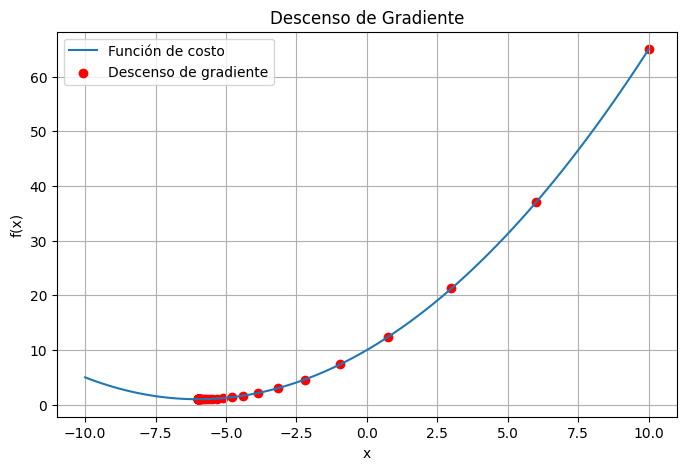

In [4]:
def f(x):
    y = 1/4*x**2 + 3*x +10     
    return y

def df(x):
    y = 1/2*x +3    #Primera derivada de la Segunda función
    return y

x = 10  # Valor inicial
learning_rate = 0.5
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(-10, 10, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()

----
## Newton-Raphson
Este método consiste en encontrar las raíces de una función, a través de iteraciones, donde el valor de x a evaluar se calcula como el valor de x actual, menos la función evaluada en el punto dividida en la derivada de la misma función, evaluada en el mismo punto:

$$ x_i = x_0 - \frac{f(x_0)}{f'(x_0)} $$

Ahora, si este método lo aplicamos a una derivada de una función, en vez de la función como tal, se pueden encontrar las raíces de la derivada, que vendrían siendo los puntos críticos (posibles óptimos) de la función original:

$$ x_i = x_0 - \frac{f'(x_0)}{f''(x_0)} $$

De manera visual, con curvas de nivel para la función $$ x^2 + 2y^2 $$

1 -0.6774393168245545
0.3545757196177274 -0.6188601076665294
0.7019147145049758 -0.8233595933668295
0.6791732797330075 -0.8242391053196632
0.6795785389928805 -0.8242393984760504
se utilizaron 4 iteraciones para encontrar el primer minimo local


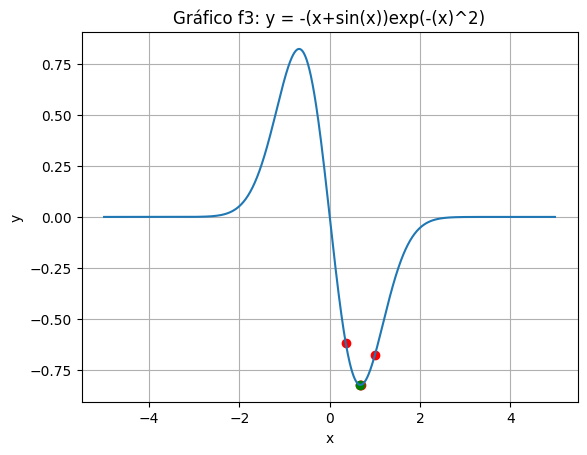

In [5]:
def f3(x):
    y = -(x+np.sin(x))*np.exp(-(x)**2)
    return y

def df3(x):
    y = np.exp(-x**2)*(2*x*np.sin(x) + 2*(x**2) - np.cos(x) - 1)    #Primera derivada de la tercera función
    return y
def d2f3(x):
    y = np.exp(-x**2)*(-4*x**3-4*(x**2)*np.sin(x) + 6*x + 4*x*np.cos(x) + 3*np.sin(x)) #Segunda derivada de la tercera función
    return y

ub = 5
lb = -5

cont = 0
l = 1
while l <= ub:
  cont +=1
  print(l, f3(l))
  l1= l - (df3(l)/d2f3(l))
  plt.scatter(x = l, y = f3(l) ,color = "red")
  if abs(l-l1) <= 0.01:
    print(l1, f3(l1))
    plt.scatter(x = l, y = f3(l) ,color = "green")
    print("se utilizaron", cont, "iteraciones para encontrar el primer minimo local")
    break
  if cont == 500:
    print("Error, el programa ha pasado el limite de 500 iteraciones")
    break
  l = l1
  
x = np.arange(-5,5,0.01)
y = -(x+np.sin(x))*np.exp(-(x)**2)
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gráfico f3: y = -(x+sin(x))exp(-(x)^2)')
plt.grid()
plt.show()

## Tarea:
En pareja utilicen estos 3 metodos de optimizacion para las siguientes funciones:

$$ y = -(1.4-3x)sin(18x) $$
$$ y = \frac{(x^2)}{3}-x+1/2 $$

Deben enviar un informe (puede ser un documento word o estar todo dentro de un notebook) mostrando y analizando sus resultados, alguna falla del algoritmo (si es que la hay) y las constantes de aprendizaje que utilizaron y por qué, junto al codigo realizado.

MÉTODO 1: Gradiente-Descendente con dirección normalizada


El algoritmo de Gradiente-Descendente con dirección normalizada es útil para encontrar mínimos locales de funciones, pero no garantiza encontrar el mínimo global, especialmente en funciones no convexas y oscilatorias como la analizada. Para identificar el mínimo global, es recomendable graficar toda la función en el intervalo de interés y analizar visualmente sus comportamientos.

Los resultados obtenidos dependen fuertemente de las constantes utilizadas, en particular del punto inicial y del learning rate (tamaño de paso). Un valor de learning rate muy bajo mejora la precisión pero aumenta el número de iteraciones, mientras que un valor demasiado alto puede provocar que el algoritmo se salte el mínimo o incluso entre en un ciclo sin converger.

Se usaron valores cercanos al origen y valores lejanos para comparar los diferentes resultados, ademas de la precision usando el learning rate.

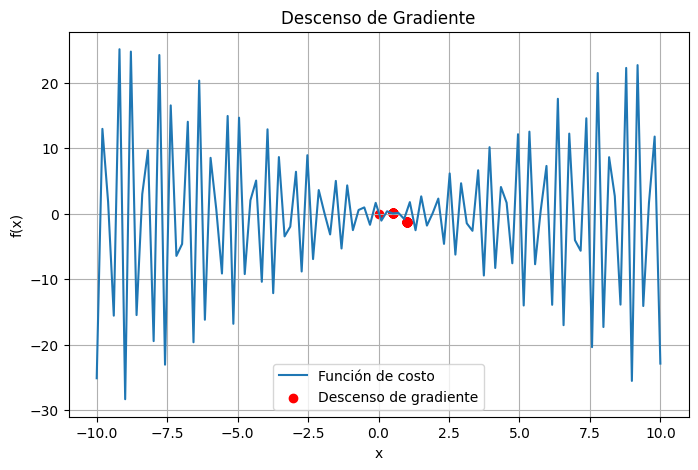

Punto inicial (x0): 0
Total iteraciones (N): 101
Mínimo encontrado (xN): 1.0
Valor de f(xN): -1.20158


,Función,x0,N,xN,x* (estimado),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) = -(1.4 - 3x)*sin(18x),0,101,1.0,0,-1.20158,-0.0,1.20158


In [6]:
def f(x):
    y = -(1.4-3*x)*np.sin(18*x)  
    return y

def df(x):
    y = 3*np.sin(18*x) -(1.4-3*x)*18*np.cos(18*x) #Primera derivada de la Segunda función
    return y

x = 0  # Valor inicial
learning_rate = 0.5
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)/np.linalg.norm(df(x))
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(-10, 10, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()
# Mostrar datos relevantes
x0 = x_history[0] # Punto inicial
xN = x_history[-1] # Minimo encontrado
N = len(x_history) # Total iteraciones
f_xN = f(xN) # 

x_real = 0
f_real = f(x_real)
diferencia = abs(f_xN - f_real)

print("Punto inicial (x0):", round(x0, 4))
print("Total iteraciones (N):", N)
print("Mínimo encontrado (xN):", round(xN, 6))
print("Valor de f(xN):", round(f_xN, 6))


# Crear un diccionario con los datos
data = {
    "Función": ["f(x) = -(1.4 - 3x)*sin(18x)"],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (estimado)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}

# Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar la tabla
display(df_resultados)



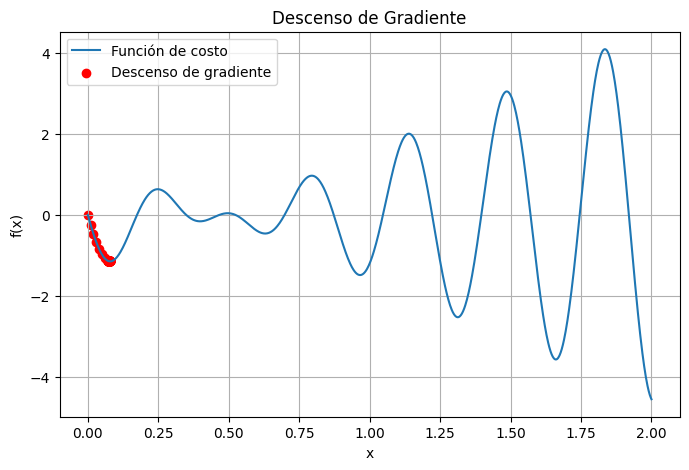

Punto inicial (x0): 0
Total iteraciones (N): 101
Mínimo encontrado (xN): 0.08
Valor de f(xN): -1.150092


,Función,x0,N,xN,x* (estimado),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) = -(1.4 - 3x)*sin(18x),0,101,0.08,0,-1.150092,-0.0,1.150092


In [7]:
def f(x):
    y = -(1.4-3*x)*np.sin(18*x)  
    return y

def df(x):
    y = 3*np.sin(18*x) -(1.4-3*x)*18*np.cos(18*x) #Primera derivada de la Segunda función
    return y

x = 0  # Valor inicial
learning_rate = 0.01
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)/np.linalg.norm(df(x))
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(0, 2, 1000)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()

# Mostrar datos relevantes
x0 = x_history[0] # Punto inicial
xN = x_history[-1] # Minimo encontrado
N = len(x_history) # Total iteraciones
f_xN = f(xN) # 

x_real = 0
f_real = f(x_real)
diferencia = abs(f_xN - f_real)

print("Punto inicial (x0):", round(x0, 4))
print("Total iteraciones (N):", N)
print("Mínimo encontrado (xN):", round(xN, 6))
print("Valor de f(xN):", round(f_xN, 6))


# Crear un diccionario con los datos
data = {
    "Función": ["f(x) = -(1.4 - 3x)*sin(18x)"],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (estimado)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}

# Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar la tabla
display(df_resultados)




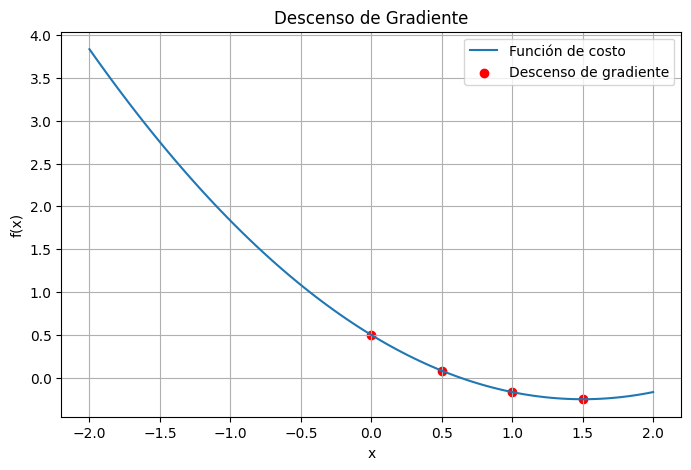

,Función,x0,N,xN,x* (real),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) = x²/3 - x + 0.5,0,4,1.5,1.5,-0.25,-0.25,0.0


In [8]:
def f(x):
    y =  (x**2)/3-x+(1/2)
    return y

def df(x):
    y = (2*x/3)-1 #Primera derivada de la Segunda función
    return y

x = 0  # Valor inicial
learning_rate = 0.5
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)/np.linalg.norm(df(x))
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(-2, 2, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()

x_real = 1.5  # Se obtiene resolviendo df(x) = 0
f_real = f(x_real)
xN = x_history[-1]
f_xN = f(xN)
N = len(x_history)
diferencia = abs(f_xN - f_real)


data = {
    "Función": ["f(x) = x²/3 - x + 0.5"],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (real)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}
df_resultados = pd.DataFrame(data)

display(df_resultados)



MÉTODO 2: Gradiente-Descendente con paso fijo

observacion: Para este caso se necesita de un valor de learning rate bajo y de muchas iteraciones para poder obtener el minimo, ya que al usar valores grandes, provoca que el algoritmo falle, entrando en bucle de saltos. La eleccion de un buen punto inicial tambien es muy importante.


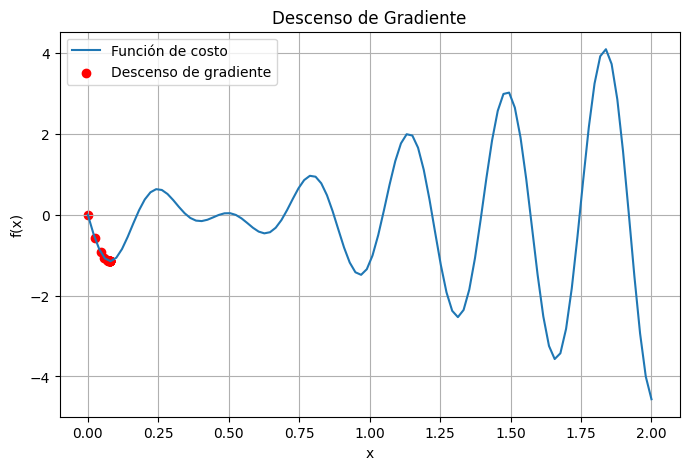

Punto inicial (x0): 0
Total iteraciones (N): 18
Mínimo encontrado (xN): 0.079332
Valor de f(xN): -1.150173


,Función,x0,N,xN,x* (estimado),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) = -(1.4 - 3x)*sin(18x),0,18,0.079332,0,-1.150173,-0.0,1.150173


In [9]:
def f(x):
    y =  -(1.4-3*x)*np.sin(18*x)  
    return y

def df(x):
    y = 3*np.sin(18*x) -(1.4-3*x)*18*np.cos(18*x) 
    return y

x = 0 # Valor inicial
learning_rate = 0.001
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(0, 2, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()

# Mostrar datos relevantes
x0 = x_history[0] # Punto inicial
xN = x_history[-1] # Minimo encontrado
N = len(x_history) # Total iteraciones
f_xN = f(xN) # 

x_real = 0
f_real = f(x_real)
diferencia = abs(f_xN - f_real)

print("Punto inicial (x0):", round(x0, 4))
print("Total iteraciones (N):", N)
print("Mínimo encontrado (xN):", round(xN, 6))
print("Valor de f(xN):", round(f_xN, 6))


# Crear un diccionario con los datos
data = {
    "Función": ["f(x) = -(1.4 - 3x)*sin(18x)"],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (estimado)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}

# Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar la tabla
display(df_resultados)



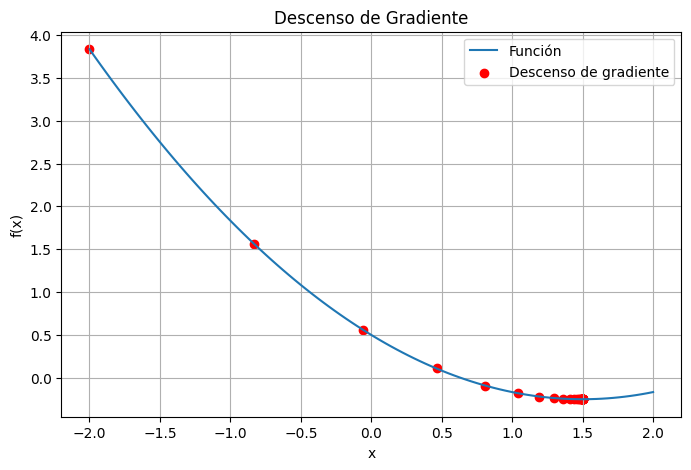

Punto inicial (x0): -2
Total iteraciones (N): 30
Mínimo encontrado (xN): 1.499973
Valor de f(xN): -0.25


,Función,x0,N,xN,x* (estimado),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) = (x**2)/3-x+(1/2),-2,30,1.499973,1.5,-0.25,-0.25,2.498745e-10


In [10]:
def f(x):
    y = (x**2)/3-x+(1/2)
    return y

def df(x):
    y =  (2*x/3)-1   #Primera derivada de la Segunda función
    return y

x = -2 # Valor inicial
learning_rate = 0.5
tol = 1e-5
max_iters = 1000

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(-2, 2, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.grid()
plt.show()

# Mostrar datos relevantes
x0 = x_history[0] # Punto inicial
xN = x_history[-1] # Minimo encontrado
N = len(x_history) # Total iteraciones
f_xN = f(xN) # 

x_real = 1.5
f_real = f(x_real)
diferencia = abs(f_xN - f_real)

print("Punto inicial (x0):", round(x0, 4))
print("Total iteraciones (N):", N)
print("Mínimo encontrado (xN):", round(xN, 6))
print("Valor de f(xN):", round(f_xN, 6))


# Crear un diccionario con los datos
data = {
    "Función": ["f(x) = (x**2)/3-x+(1/2)"],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (estimado)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}

# Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar la tabla
display(df_resultados)



MÉTODO 3: Newton-Raphson


Para el primer caso: 

-Newton-Raphson puede ser peligroso en este tipo de funciones.

-Si parte lejos del mínimo, el método puede saltar de un lado a otro.

-Puede caer en un máximo o en un punto de inflexión (porque solo busca f′(x)=0, y eso no asegura mínimo).

-El denominador f′′(x) puede ser muy pequeño o cambiar de signo, generando saltos grandes o divisiones por cero.

Para el segundo caso:

-El método converge en un solo paso si empieza en cualquier punto (porque la segunda derivada es constante).

-Es eficiente y exacto.

1 -1.201579594834682
0.9636057024484411 -1.4875572059860709
0.9660996456797644 -1.489072491326017
se utilizaron 2 iteraciones para encontrar el primer minimo local


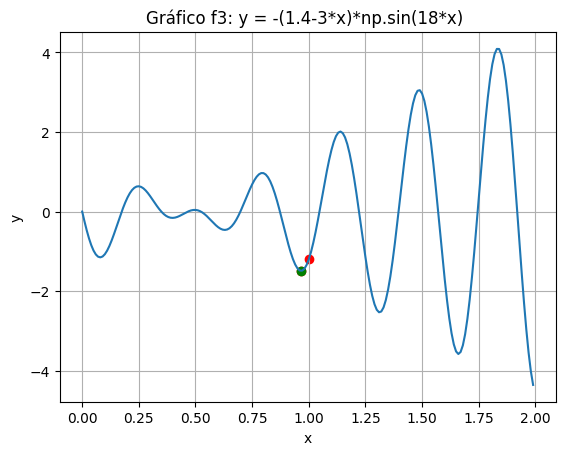

Punto inicial (x0): -2
Total iteraciones (N): 30
Mínimo encontrado (xN): 1.499973
Valor de f(xN): -0.25


,Función,x0,N,xN,x* (estimado),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) = -(1.4 - 3x)*sin(18x),-2,30,1.499973,0,-0.25,0.5,0.75


In [11]:
def f3(x):
    y =  -(1.4-3*x)*np.sin(18*x)  
    return y

def df3(x):
    y = 3*np.sin(18*x) -(1.4-3*x)*18*np.cos(18*x)
    return y
def d2f3(x):
    y = 108*np.cos(18*x)+453.6*np.sin(18*x)-972*x*np.sin(18*x)
    return y

ub = 5
lb = -5

cont = 0
l = 1
while l <= ub:
  cont +=1
  print(l, f3(l))
  l1= l - (df3(l)/d2f3(l))
  plt.scatter(x = l, y = f3(l) ,color = "red")
  if abs(l-l1) <= 0.01:
    print(l1, f3(l1))
    plt.scatter(x = l, y = f3(l) ,color = "green")
    print("se utilizaron", cont, "iteraciones para encontrar el primer minimo local")
    break
  if cont == 500:
    print("Error, el programa ha pasado el limite de 500 iteraciones")
    break
  l = l1
  
x = np.arange(0,2,0.01)
y = -(1.4-3*x)*np.sin(18*x) 
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gráfico f3: y = -(1.4-3*x)*np.sin(18*x) ')
plt.grid()
plt.show()

# Mostrar datos relevantes
x0 = x_history[0] # Punto inicial
xN = x_history[-1] # Minimo encontrado
N = len(x_history) # Total iteraciones
f_xN = f(xN) # 

x_real = 0
f_real = f(x_real)
diferencia = abs(f_xN - f_real)

print("Punto inicial (x0):", round(x0, 4))
print("Total iteraciones (N):", N)
print("Mínimo encontrado (xN):", round(xN, 6))
print("Valor de f(xN):", round(f_xN, 6))


# Crear un diccionario con los datos
data = {
    "Función": ["f(x) = -(1.4 - 3x)*sin(18x)"],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (estimado)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}

# Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar la tabla
display(df_resultados)



0 0.5
1.5 -0.25
1.5 -0.25
se utilizaron 2 iteraciones para encontrar el primer minimo local


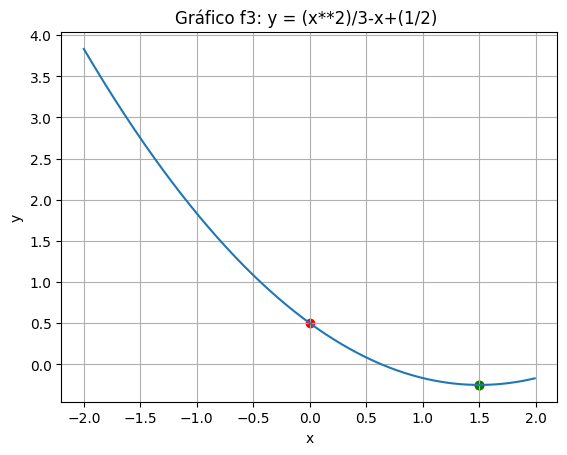

Punto inicial (x0): -2
Total iteraciones (N): 30
Mínimo encontrado (xN): 1.499973
Valor de f(xN): -0.25


,Función,x0,N,xN,x* (estimado),f(xN),f(x*),|f(xN) - f(x*)|
0,f(x) =(x**2)/3-x+(1/2),-2,30,1.499973,1.5,-0.25,-0.25,2.498745e-10


In [12]:
def f3(x):
    y = (x**2)/3-x+(1/2)
    return y

def df3(x):
    y = (2*x/3)-1    #Primera derivada de la tercera función
    return y
def d2f3(x):
    y = 2/3 #Segunda derivada de la tercera función
    return y

ub = 5
lb = -5

cont = 0
l = 0
while l <= ub:
  cont +=1
  print(l, f3(l))
  l1= l - (df3(l)/d2f3(l))
  plt.scatter(x = l, y = f3(l) ,color = "red")
  if abs(l-l1) <= 0.01:
    print(l1, f3(l1))
    plt.scatter(x = l, y = f3(l) ,color = "green")
    print("se utilizaron", cont, "iteraciones para encontrar el primer minimo local")
    break
  if cont == 500:
    print("Error, el programa ha pasado el limite de 500 iteraciones")
    break
  l = l1
  
x = np.arange(-2,2,0.01)
y = (x**2)/3-x+(1/2)
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gráfico f3: y = (x**2)/3-x+(1/2) ')
plt.grid()
plt.show()

# Mostrar datos relevantes
x0 = x_history[0] # Punto inicial
xN = x_history[-1] # Minimo encontrado
N = len(x_history) # Total iteraciones
f_xN = f(xN) # 

x_real = 1.5
f_real = f(x_real)
diferencia = abs(f_xN - f_real)

print("Punto inicial (x0):", round(x0, 4))
print("Total iteraciones (N):", N)
print("Mínimo encontrado (xN):", round(xN, 6))
print("Valor de f(xN):", round(f_xN, 6))


# Crear un diccionario con los datos
data = {
    "Función": ["f(x) =(x**2)/3-x+(1/2) "],
    "x0": [x0],
    "N": [N],
    "xN": [xN],
    "x* (estimado)": [x_real],
    "f(xN)": [f_xN],
    "f(x*)": [f_real],
    "|f(xN) - f(x*)|": [diferencia]
}

# Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostrar la tabla
display(df_resultados)

